# Advanced ML Project

## Libraries and Packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Data Loading and Preliminary Analysis

In [5]:
# Load the dataset
diabetes = load_diabetes()

# Create the DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# First rows
df.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [6]:
df['target'] = diabetes.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In the scikit-learn "Diabetes" dataset, the target variable is a quantitative measure of disease progression.

It is a numerical score (ranging from 25 to 346) that represents the patient's health status with respect to diabetes. The higher the number, the more the disease has progressed (worsened) over the observation period.

Target: 25 to 346. A low target value (e.g. 50) means the disease has barely progressed. A value closer to 300 indicates significant progression over the course of the year.

The Target variable was recorded by physicians during the original study.

Scikit-learn provides data that has already been scaled and centered (zero mean, and the sum of squares of each column equals 1).

In [8]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.

The dataset contains 442 rows and no missing values. All fields are numeric — ideal for analysis.

### Heatmap
A heatmap is created to visualise the correlations between variables.

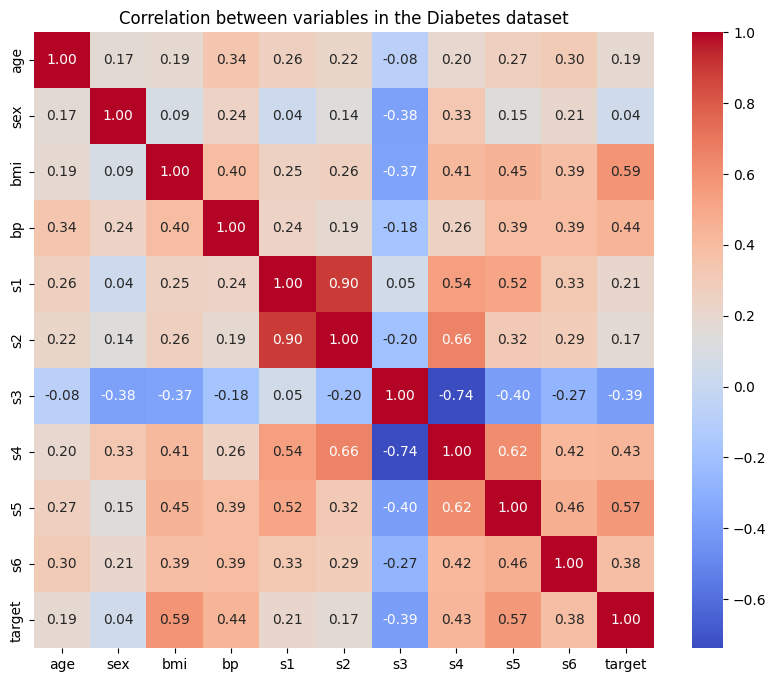

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation between variables in the Diabetes dataset")
plt.show()


First, we look at the target row/column to see which variables are most correlated with disease progression. At first glance the correlations do not appear very strong, but in medical research even moderate correlations (between 0.3 and 0.5) are considered very important signals. Three variables stand out most:

- BMI (Body Mass Index) $\approx 0.59$. This is the variable with the highest correlation. It is unsurprising that being overweight is one of the strongest predictors of worsening type-2 diabetes.
-  s5 (log of serum triglycerides) $\approx 0.57$. This variable is almost as important as BMI. Triglycerides are fats in the blood; a high value often indicates difficulty in managing insulin. The fact that it ranks so highly suggests that biochemical data are as fundamental as physical measurements.
-  bp (Mean Blood Pressure) $\approx 0.44$. Below 0.5, but in a complex system like the human body a correlation of 0.44 is not negligible. It indicates that patients with higher blood pressure tend to show faster disease progression.

### Scatter Plots
To better visualise the relationship between these 3 variables and disease progression, three scatter plots are created.

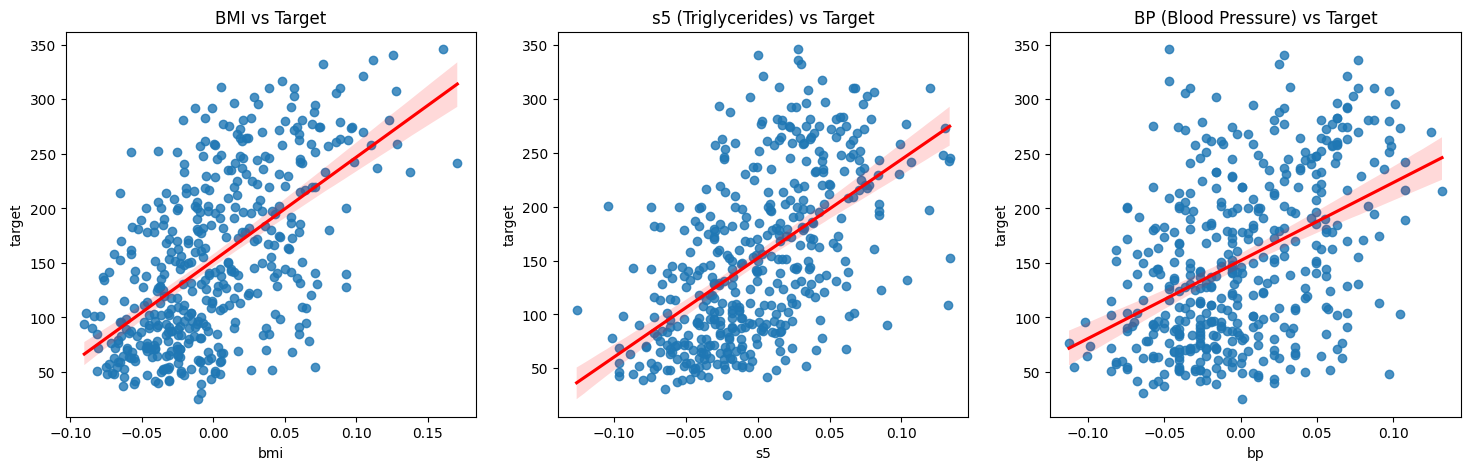

In [14]:
# Select only the top 3 features and target for a quick comparison
top_features = df[['bmi', 's5', 'bp', 'target']]

# Regression plots for the top 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=df, x='bmi', y='target', ax=axes[0], line_kws={'color':'red'})
axes[0].set_title('BMI vs Target')

sns.regplot(data=df, x='s5', y='target', ax=axes[1], line_kws={'color':'red'})
axes[1].set_title('s5 (Triglycerides) vs Target')

sns.regplot(data=df, x='bp', y='target', ax=axes[2], line_kws={'color':'red'})
axes[2].set_title('BP (Blood Pressure) vs Target')

plt.show()


It is immediately clear that the points in the rightmost plot (bp) are more dispersed. This is not surprising given the lower correlation of 0.44. The trend is still clear and the slope is fairly steep. In the other two plots the points are more concentrated and the regression lines are steeper.

## Model Selection

In this phase, a comparison strategy is defined across several regression algorithms to identify the one best suited to predicting diabetes progression. A Pipeline is used to ensure correct data standardisation, and GridSearchCV is used to optimise the hyperparameters of each model, guaranteeing a robust evaluation via Cross-Validation.

In [18]:
# Split data: 80% for training and 20% for final testing
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training dataset: {X_train.shape[0]} patients")
print(f"Test dataset: {X_test.shape[0]} patients")


Training dataset: 353 patients
Test dataset: 89 patients


The following code section serves three fundamental purposes to ensure the reliability of the results:

- **Integrated Standardisation** (Pipeline). In this case the data are already standardised, but a StandardScaler has been included anyway to make the pipeline reusable with raw data. In general, this is important to ensure that variables with different scales (e.g. Age vs Cholesterol) carry the same initial "weight", avoiding distortions in coefficient estimation.
  
- **Hyperparameter Search** (Grid Search): the code does not just test the model but searches for its optimal configuration. For example, for Lasso it tries different values of $\alpha$ to find the one that maximises predictive power without overfitting.
  
- **Cross-Validation** (5-Fold Cross-Validation): the algorithm splits the training data into 5 parts, training the model on 4 and testing it on the fifth, rotating through all combinations. Advantage: the final $R^2$ score is the average of these 5 tests, ensuring stable performance not dependent on a lucky data split.

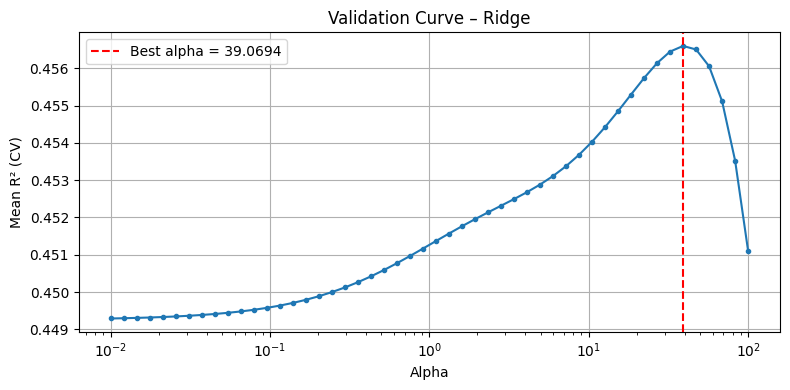

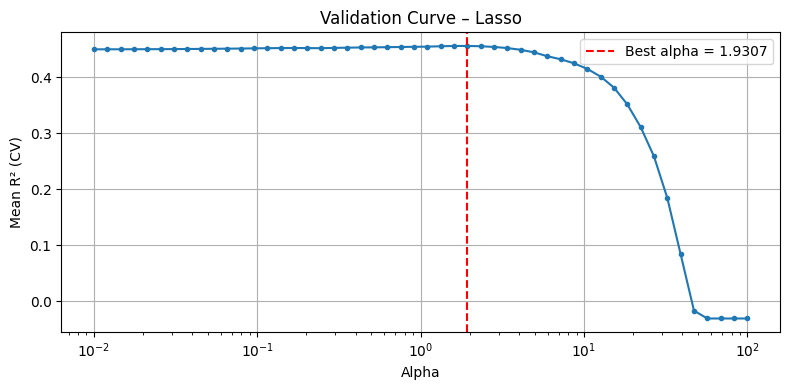

,Model,Best R2 (CV),Best Parameter
0,Ridge,0.4566,{'model__alpha': 39.06939937054613}
1,Lasso,0.4555,{'model__alpha': 1.9306977288832496}
2,Random Forest,0.4070,"{'model__max_depth': 5, 'model__n_estimators': 200}"


In [20]:
# 1. Define models and parameter grids
alphas = np.logspace(-2, 2, 50)  # 50 values from 0.01 to 100, log scale

models_to_test = [
    {
        'name': 'Ridge',
        'model': Ridge(),
        'params': {'model__alpha': alphas}
    },
    {
        'name': 'Lasso',
        'model': Lasso(max_iter=10000),  # high max_iter to ensure convergence
        'params': {'model__alpha': alphas}
    },
    {
        'name': 'Random Forest',
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [None, 5, 10]
        }
    }
]

# 2. Training loop, comparison and validation curve
results = []
for m in models_to_test:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', m['model'])
    ])
    
    grid = GridSearchCV(pipe, m['params'], cv=5, scoring='r2')
    grid.fit(X_train, y_train)
    
    # Save the best estimator directly from GridSearchCV (no hard-coding)
    best_estimator = grid.best_estimator_

    results.append({
        'Model': m['name'],
        'Best R2 (CV)': round(grid.best_score_, 4),
        'Best Parameter': grid.best_params_,
        'Grid': grid,
        'Best Estimator': best_estimator  
    })
    
    # 3. Validation curve only for models with alpha (Ridge and Lasso)
    if 'model__alpha' in m['params']:
        cv_results = grid.cv_results_
        mean_scores = cv_results['mean_test_score']
        
        plt.figure(figsize=(8, 4))
        plt.semilogx(alphas, mean_scores, marker='o', markersize=3)
        plt.axvline(grid.best_params_['model__alpha'], color='red',
                    linestyle='--', label=f"Best alpha = {grid.best_params_['model__alpha']:.4f}")
        plt.xlabel('Alpha')
        plt.ylabel('Mean R² (CV)')
        plt.title(f'Validation Curve – {m["name"]}')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# 4. Display results (without 'Best Estimator' and 'Grid' columns for readability)
df_results = pd.DataFrame(results).drop(columns=['Best Estimator','Grid'])
pd.set_option('display.max_colwidth', None)
display(df_results)


Although Ridge achieves a marginally higher R², Lasso is chosen because the difference is not significant and the model offers the added benefit of automatic feature selection, making the result more interpretable.
Regarding Random Forest, the selected max_depth = 5 suggests that the diabetes data contain noise and the model preferred a shallower tree to avoid overfitting. In general, the dataset is likely too small for a model like Random Forest to perform optimally.

During the GridSearchCV phase, the model only saw Training data. Cross-Validation was used to find the best alpha (in this case 1).
However, to know how well the model truly generalises, it must be tested on data it has never seen before: the Test Set (the 20% set aside at the beginning). The model therefore needs to be retrained with the optimal alpha and then evaluated on the Test Set.

## In-Depth Analysis of the Lasso Model
Having established the winning model, a more thorough analysis of the Lasso model is carried out.

In [24]:
# Automatically retrieve the best Lasso estimator from the previous loop
lasso_grid = next(r['Grid'] for r in results if r['Model'] == 'Lasso')
best_pipe = lasso_grid.best_estimator_  

# Final evaluation on the test set (never-seen data)
y_pred = best_pipe.predict(X_test)
r2_final = r2_score(y_test, y_pred)
mse_final = mean_squared_error(y_test, y_pred)
print(f"Final performance on Test Set: \n -R2: {r2_final:.4f}, \n- MSE: {mse_final:.2f}")


Final performance on Test Set: 
 -R2: 0.4717, 
- MSE: 2799.07


**Comments**:
- $R2 = 0.4717$. This value indicates that the model is able to explain approximately 47.2% of the variability in diabetes progression. The other half depends on factors not present in the dataset.
  
- $MSE = 2799.07$ (Mean Squared Error). To make this interpretable, we compute the square root (RMSE):                            $$\sqrt{2799.07} \approx 52.91$$                                                                                                   This means the model's predictions are off by roughly 53 points. For example, if the model predicts a disease progression score of 150 for a patient, the real value will likely fall between 97 and 203. Given that the disease scale in the dataset ranges from 25 to 346, an error of about 53 is acceptable for risk assessment purposes, but not for a precise diagnosis.

### Coefficient Analysis

Variables excluded by the model: ['age', 's2', 's4']


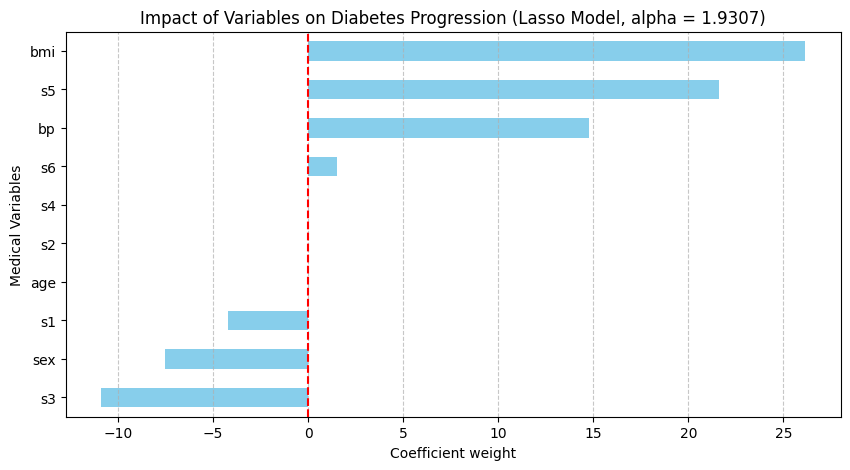

In [27]:
# Extract the coefficients
coef_series = pd.Series(best_pipe.named_steps['model'].coef_, index=diabetes.feature_names)
# Identify excluded variables
excluded = coef_series[coef_series == 0].index.tolist()
print(f"Variables excluded by the model: {excluded}")
# Plot to visualise all coefficients
plt.figure(figsize=(10, 5))
coef_series.sort_values().plot(kind='barh', color='skyblue')
best_alpha = lasso_grid.best_params_['model__alpha']
plt.title(f"Impact of Variables on Diabetes Progression (Lasso Model, alpha = {best_alpha:.4f})")
plt.xlabel("Coefficient weight")
plt.ylabel("Medical Variables")
plt.axvline(x=0, color='red', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [28]:
print(coef_series)

age     0.000000
sex    -7.537984
bmi    26.150560
bp     14.797112
s1     -4.214568
s2     -0.000000
s3    -10.911430
s4      0.000000
s5     21.596436
s6      1.521781
dtype: float64


The zeroed-out coefficients belong to age, s2 (LDL), and s4 (total cholesterol/HDL). The model has determined that, given the other variables, these 3 are irrelevant for predicting disease progression.
This suggests that to monitor diabetes progression over one year, physicians can focus on a leaner set of indicators, optimising resources and analysis time.
The model is as accurate as Ridge regression while using less information.

### Residual Analysis

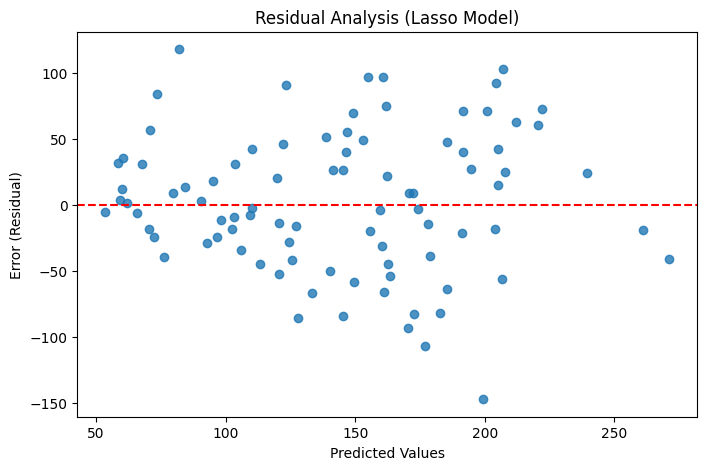

In [31]:
# Residual analysis
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.8)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Analysis (Lasso Model)")
plt.xlabel("Predicted Values")
plt.ylabel("Error (Residual)")
plt.show()


The points are scattered with no discernible pattern. This is a good sign — it means the model has not overlooked important information.

## Ridge vs Lasso Comparison

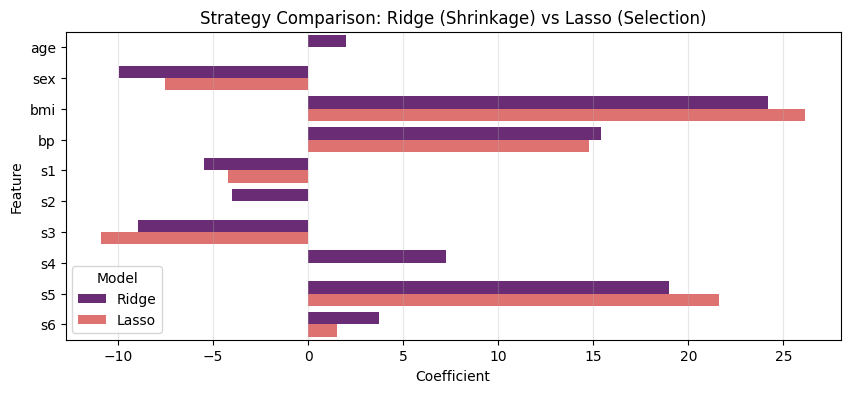

In [34]:
# Retrieve Ridge and Lasso coefficients from the best estimators found by CV
ridge_grid = next(r['Grid'] for r in results if r['Model'] == 'Ridge')  # same approach as for Lasso above

ridge_final = ridge_grid.best_estimator_.named_steps['model']
lasso_final = lasso_grid.best_estimator_.named_steps['model']

df_compare = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Ridge': ridge_final.coef_,
    'Lasso': lasso_final.coef_
}).melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

plt.figure(figsize=(10, 4))
sns.barplot(data=df_compare, x='Coefficient', y='Feature', hue='Model', palette='magma')
plt.title("Strategy Comparison: Ridge (Shrinkage) vs Lasso (Selection)")
plt.grid(axis='x', alpha=0.3)
plt.show()


Below are some observations on the bars shown in the chart.
- **BMI, s5 and bp**. Both Ridge and Lasso agree almost perfectly on their importance. The bars are long and positive.
  
- **s2**. Ridge regression assigns a small negative weight to this variable, whereas Lasso ignores it entirely.
  
- **sex, s1 and s3**. Both models recognise these as important factors, but with a negative sign. In this dataset, higher values of these variables are associated with lower disease progression. Lasso is noticeably more aggressive than Ridge in reducing the weight of s1 — a further demonstration of its selective nature.

In summary, both models identify BMI, s5 and bp as the strongest positive predictors, confirming their clinical relevance. The crucial difference lies in how less informative variables are handled: while Ridge retains all coefficients, Lasso completely zeroes out s2 and drastically reduces the impact of s4, demonstrating its ability to perform automatic feature selection for a simpler and more interpretable model.

In [37]:
# Create an average patient using a DataFrame with the correct column names
average_patient = pd.DataFrame(np.zeros((1, 10)), columns=diabetes.feature_names)

# Prediction
base_prediction = best_pipe.predict(average_patient)[0]

print(f"Baseline progression value for an average patient: {base_prediction:.2f}")


Baseline progression value for an average patient: 151.56


## Conclusions
At the end of this predictive study, based on a dataset of 442 patients and 10 clinical variables, the following conclusions can be drawn:

- **Model Effectiveness**. The Lasso model (L1 regularisation) with α ≈ 1.9307 proved to be the best-performing model, achieving an R² of 0.4717 on the test set. This indicates that almost half of the year-on-year variability in disease progression can be attributed solely to the clinical parameters measured at baseline.

- **Identification of Critical Factors**. Coefficient analysis unambiguously confirmed that Body Mass Index (BMI) and triglycerides (s5) are the most influential predictors. A targeted intervention on these two factors could have a significant impact on slowing disease progression.

- **Resource Optimisation**. Thanks to Lasso's feature selection property, it has been shown that the variables s2 (LDL), s4 (total cholesterol/HDL), and age are redundant for prediction purposes. In a large-scale screening context, organisations could potentially reduce the number of tests required without losing diagnostic accuracy.

- **Limitations and Future Work**. The residual error (RMSE ≈ 53) suggests that the clinical picture is influenced by variables not present in the dataset (e.g. physical activity, diet, genetics). To exceed the 50% accuracy threshold, it would be necessary to integrate patients' behavioural data.
